# Preprocesamiento de Datos - Telco Customer Churn

**Objetivo:** A partir de los hallazgos del EDA (`EDA.ipynb`), aplicar de forma sistemática los pasos de limpieza, codificación y escalado necesarios para dejar los datos listos para el modelado, evitando *data leakage* entre `train` y `test`.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42

# Nota: se retira `warnings.filterwarnings('ignore')`. Ocultar todos los avisos
# también oculta RuntimeWarning legítimos (p. ej. divisiones por cero reales),
# como el que aparecía silenciado en la sección 4.3.b. Si algún aviso puntual
# es inevitable y ya está explicado, se silencia localmente con `np.errstate`
# justo en esa operación, no de forma global.


## 2. Carga de datos y variable objetivo

In [2]:
df = pd.read_csv(r'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.columns = df.columns.str.strip()

TARGET = 'Churn'
if TARGET not in df.columns:
    posibles_target = [col for col in df.columns if 'churn' in col.lower()]
    if posibles_target:
        TARGET = posibles_target[0]

print(f"Dimensiones del dataset completo: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset completo: 7043 filas x 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Disponibilidad temporal de las variables (instante de predicción)

Antes de dividir los datos conviene dejar explícito **cuándo** estaría disponible cada variable si este modelo se usara para predecir *hacia adelante* (churn futuro), y no solo para clasificar retrospectivamente un corte ya cerrado. Esto no cambia el preprocesamiento, pero condiciona qué tan literal puede ser la lectura de las métricas como "capacidad predictiva".

| Momento | Variables | Comentario |
|---|---|---|
| Conocidas desde el alta del cliente | `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `InternetService`, `Contract`, `PaymentMethod`, `PaperlessBilling` | Estables o de baja frecuencia de cambio; disponibles en cualquier instante posterior al alta. |
| Acumulativas / dependientes del corte | `tenure`, `TotalCharges`, `MonthlyCharges`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Reflejan el estado del cliente **en la fecha del corte del dataset**, no en el futuro. |
| Derivada del target | — | Ninguna variable se deriva de `Churn`; ver hallazgo sobre target leakage más abajo. |

**Punto importante (no es *leakage* en sentido estricto, pero sí una limitación de alcance).** Según la documentación habitual de este dataset (IBM Telco Customer Churn), `Churn = Yes` significa que el cliente se fue **en el último mes** antes del corte. Si es así, para los clientes que sí abandonaron, `tenure` y `TotalCharges` pueden quedar "congelados" en el momento de la baja, mientras que para los que permanecen esas mismas variables siguen acumulándose después del corte. Los 8 registros con `TotalCharges` nulo y `tenure = 0` (ver sección 6 del EDA) son consistentes con esto: todos son `Churn = No`, es decir, clientes recién dados de alta que aún no pudieron irse.

En consecuencia, lo que este modelo mide es **distinguir churners de no-churners dentro de un mismo corte**, no una predicción prospectiva sobre clientes activos hoy. Ambas lecturas son legítimas, pero deben nombrarse: si el objetivo de negocio es "predecir quién se va a ir el próximo mes", este pipeline es un buen punto de partida, no el modelo final — un uso prospectivo real necesitaría variables medidas *antes* del posible corte de cada cliente, no en el mismo corte.


## 3. División train / test

Se replica la misma partición estratificada usada en el EDA (misma `random_state`), para mantener consistencia entre ambos notebooks.

Inmediatamente después de partir los datos se verifica que no haya solapamiento de índices y se cuantifican los perfiles idénticos entre `train` y `test` (ver celda siguiente), antes de tocar el contenido de las variables.

In [3]:
#Utilizar el mismo train/tes del EDA para que los resultados sean consistentes.
import pickle

with open('train_test_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)


print(f"Train: {X_train.shape[0]} Clientes, Test: {X_test.shape[0]} Clientes")

Train: 5634 Clientes, Test: 1409 Clientes


In [4]:
# Verificación del split: sin solapamiento de índices entre train y test
assert X_train.index.intersection(X_test.index).empty, "Hay índices repetidos entre train y test"

# Perfiles idénticos entre train y test (mismas variables predictoras), comparando también la etiqueta.
# Es solo un diagnóstico de independencia: NO se usa para modificar train, test ni el modelo.
cols_originales = X_train.columns.tolist()
duplicados_tt = (
    X_test.assign(**{TARGET: y_test}).rename_axis('idx_test').reset_index()
    .merge(X_train.assign(**{TARGET: y_train}).drop_duplicates(),
           on=cols_originales, suffixes=('_test', '_train'))
)
mismo_target = duplicados_tt[TARGET + '_test'] == duplicados_tt[TARGET + '_train']
n_filas_test = duplicados_tt['idx_test'].nunique()
print(f"Filas de test con algún perfil idéntico en train: {n_filas_test} de {len(X_test)} ({100 * n_filas_test / len(X_test):.2f}%)")
print(f"Parejas train/test coincidentes: {len(duplicados_tt)} | misma etiqueta: {mismo_target.sum()} | etiqueta distinta: {(~mismo_target).sum()}")

# Trazabilidad de la partición: el EDA y este notebook deben usar exactamente el mismo split.
# Si los índices ya existen (los guarda el primero de los dos notebooks que se ejecuta), se VERIFICAN;
# si no existen, se guardan. Compara los índices, no solo los tamaños.
from pathlib import Path
IDX_TRAIN, IDX_TEST = Path('train_index.csv'), Path('test_index.csv')
if IDX_TRAIN.exists() and IDX_TEST.exists():
    ref_train = set(pd.read_csv(IDX_TRAIN)['train_index'])
    ref_test = set(pd.read_csv(IDX_TEST)['test_index'])
    assert ref_train == set(X_train.index) and ref_test == set(X_test.index),         "La partición difiere de la guardada previamente: revisar archivo, orden de filas o semilla"
    print("✔ Partición idéntica a la guardada previamente (mismos índices de train y test).")
else:
    pd.Series(X_train.index, name='train_index').to_csv(IDX_TRAIN, index=False)
    pd.Series(X_test.index, name='test_index').to_csv(IDX_TEST, index=False)
    print("Índices de la partición guardados en train_index.csv / test_index.csv")


Filas de test con algún perfil idéntico en train: 13 de 1409 (0.92%)
Parejas train/test coincidentes: 14 | misma etiqueta: 7 | etiqueta distinta: 7
✔ Partición idéntica a la guardada previamente (mismos índices de train y test).


## 4. Pasos de preprocesamiento definidos a partir del EDA

1. **Manejo del target:** convertir `Churn` de 'Yes'/'No' a 1/0.
2. **Manejo de `TotalCharges`:** convertir a numérico e imputar los nulos (clientes nuevos con `tenure = 0`) con **0**.
3. **Ingeniería de características:**
   - Colapsar las categorías redundantes "No internet service" / "No phone service" (el EDA confirmó 0 discrepancias con `InternetService`/`PhoneService`: es información 100% duplicada).
   - Crear `AvgChargePerMonth` (cargo promedio histórico) para aprovechar la relación `tenure`–`TotalCharges` (r = 0.83) sin eliminar ninguna de las dos variables originales.
   - Conservar `gender` y `PhoneService` aunque el EDA no encontró asociación bivariada significativa con Churn: un test bivariado no ve interacciones con otras variables, así que se conservan y su aporte se evalúa después con una ablación por validación cruzada dentro de `train` (sección 4.7), no leyendo coeficientes sueltos.
4. **Codificación de variables categóricas:**
   - Variables nominales (más de 2 categorías, incluyendo binarias tipo Yes/No): One-Hot Encoding (OHE).
5. **Escalado de variables numéricas:** `tenure`, `MonthlyCharges`, `TotalCharges` y `AvgChargePerMonth` se estandarizan con `StandardScaler`.

El escalado (`StandardScaler`) y la codificación (`OneHotEncoder`) **aprenden sus parámetros únicamente de `train`** y luego se aplican a `test`. La imputación de `TotalCharges` es distinta: **no es un parámetro aprendido**, es la constante fija 0, justificada por el contexto (`tenure = 0`) y aplicada igual a ambos conjuntos — ver sección 4.2 para la verificación explícita de esa condición. Ninguna de las dos formas de tratamiento usa información de `test` para decidirse, así que no hay *data leakage*.

### 4.1 Manejo del target

In [5]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

print(y_train.value_counts(normalize=True))

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


### 4.2 Manejo de `TotalCharges`

In [6]:
# Convertir a numérico, forzando errores (espacios en blanco) a NaN
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

print("Nulos en TotalCharges (train) antes de imputar:", X_train['TotalCharges'].isnull().sum())
print("Nulos en TotalCharges (test) antes de imputar:", X_test['TotalCharges'].isnull().sum())

# Se verifica explícitamente la condición que justifica imputar con 0: todo nulo
# de TotalCharges debe corresponder a un cliente con tenure = 0 (recién dado de
# alta, aún sin cargo acumulado). Si esto fallara para algún registro de test,
# la regla "clientes nuevos" no lo cubriría y no debería aplicarse ciegamente.
assert (X_train.loc[X_train['TotalCharges'].isna(), 'tenure'] == 0).all(), \
    "Hay nulos en TotalCharges (train) con tenure != 0: la justificación de imputar con 0 no aplica"
assert (X_test.loc[X_test['TotalCharges'].isna(), 'tenure'] == 0).all(), \
    "Hay nulos en TotalCharges (test) con tenure != 0: la justificación de imputar con 0 no aplica"

# Imputar con 0 (clientes nuevos, tenure = 0), decisión basada en el hallazgo del EDA
# y ahora verificada explícitamente arriba, no solo asumida.
X_train['TotalCharges'] = X_train['TotalCharges'].fillna(0)
X_test['TotalCharges'] = X_test['TotalCharges'].fillna(0)

print("Nulos en TotalCharges (train) después de imputar:", X_train['TotalCharges'].isnull().sum())
print("Nulos en TotalCharges (test) después de imputar:", X_test['TotalCharges'].isnull().sum())


Nulos en TotalCharges (train) antes de imputar: 8
Nulos en TotalCharges (test) antes de imputar: 3
Nulos en TotalCharges (train) después de imputar: 0
Nulos en TotalCharges (test) después de imputar: 0


**¿Importa la elección de imputación?** Se compara, solo dentro de `train` y por validación cruzada (sin tocar `test`), la imputación actual (constante 0) contra una alternativa más convencional: mediana de `TotalCharges` + una columna indicadora de que el valor fue imputado, con la mediana **aprendida dentro de cada fold** (`SimpleImputer` dentro del `Pipeline`, no calculada de antemano con todo `train`). Esto responde de forma cuantitativa, no solo cualitativa, si "el impacto es prácticamente nulo".

In [7]:
# Alternativa: mediana de TotalCharges + indicador de imputación, APRENDIDOS dentro de cada fold
# (SimpleImputer dentro del Pipeline). Se evalúa por CV solo dentro de train; test no se toca.
# Se compara antes de crear AvgChargePerMonth, sobre las variables base.

# Versión sin imputar de TotalCharges (NaN en los clientes con tenure = 0), solo filas de train
X_train_alt = X_train.copy()
X_train_alt['TotalCharges'] = pd.to_numeric(df.loc[X_train.index, 'TotalCharges'], errors='coerce')

numeric_features_base = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features_base = [c for c in X_train.columns if c not in numeric_features_base]

def pipeline_base(imputador=None):
    pasos_num = ([('imp', imputador)] if imputador is not None else []) + [('sc', StandardScaler())]
    prep = ColumnTransformer([
        ('num', Pipeline(pasos_num), numeric_features_base),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features_base)
    ])
    return Pipeline([('prep', prep),
                     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])

cv_check = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
auc_cv_0 = cross_val_score(pipeline_base(), X_train, y_train, cv=cv_check, scoring='roc_auc')
auc_cv_alt = cross_val_score(pipeline_base(SimpleImputer(strategy='median', add_indicator=True)),
                             X_train_alt, y_train, cv=cv_check, scoring='roc_auc')
dif = auc_cv_alt - auc_cv_0

print(f"Mediana de TotalCharges en train (informativa; en cada fold el imputador aprende la suya): {X_train_alt['TotalCharges'].median():.2f}")
print(f"CV AUC-ROC · imputación con 0 (actual, sin AvgChargePerMonth aún):     {auc_cv_0.mean():.4f} ± {auc_cv_0.std():.4f}")
print(f"CV AUC-ROC · mediana + indicador (alternativa, sin AvgChargePerMonth): {auc_cv_alt.mean():.4f} ± {auc_cv_alt.std():.4f}")
print(f"Diferencia pareada por fold (alternativa − 0): {dif.mean():+.4f} ± {dif.std():.4f}")


Mediana de TotalCharges en train (informativa; en cada fold el imputador aprende la suya): 1398.12
CV AUC-ROC · imputación con 0 (actual, sin AvgChargePerMonth aún):     0.8460 ± 0.0124
CV AUC-ROC · mediana + indicador (alternativa, sin AvgChargePerMonth): 0.8460 ± 0.0125
Diferencia pareada por fold (alternativa − 0): +0.0001 ± 0.0001


**Conclusión medible:** con solo 8 registros afectados en train (0.14%), el AUC-ROC por CV es prácticamente idéntico entre imputar con 0 (0.8460 ± 0.0124) y usar mediana + indicador (0.8460 ± 0.0125); la diferencia pareada por fold (+0.0001 ± 0.0001) queda muy por debajo de la desviación estándar entre folds. La elección no es crítica para el desempeño. Se mantiene la imputación con 0 porque además es más interpretable en este caso (0 cargos acumulados para un cliente sin antigüedad, en vez de un valor "promedio" que nunca observó), y porque la verificación de la celda anterior confirma que la condición que la justifica (`tenure = 0`) se cumple siempre, en train y en test.

Esto responde a la duda del EDA con evidencia y no con una afirmación: el impacto medido por CV es despreciable con este dataset. No se generaliza a otros datos donde la ausencia tenga otra causa.


### 4.3 Ingeniería de características a partir del EDA

**a) Colapsar categorías redundantes.** El EDA confirmó (sección de consistencia, "0 discrepancias") que "No internet service" y "No phone service" son información 100% duplicada con `InternetService`/`PhoneService`. La información no se pierde, porque sigue disponible en `InternetService` y `PhoneService`, que se conservan; colapsar elimina columnas redundantes del One-Hot Encoding. Lo que sí cambia es la parametrización y, con regularización L2, eso puede alterar levemente la penalización efectiva, así que no se afirma que las predicciones sean idénticas.

In [8]:
# Colapsar categorías redundantes detectadas en el EDA:
# "No internet service" y "No phone service" ya están implícitas en
# InternetService y PhoneService respectivamente — mantenerlas duplica esa información
cols_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_no_internet:
    X_train[col] = X_train[col].replace('No internet service', 'No')
    X_test[col] = X_test[col].replace('No internet service', 'No')

X_train['MultipleLines'] = X_train['MultipleLines'].replace('No phone service', 'No')
X_test['MultipleLines'] = X_test['MultipleLines'].replace('No phone service', 'No')

print("Categorías únicas tras colapsar (ejemplo, OnlineSecurity):", X_train['OnlineSecurity'].unique())
print("Categorías únicas tras colapsar (MultipleLines):", X_train['MultipleLines'].unique())

Categorías únicas tras colapsar (ejemplo, OnlineSecurity): ['No' 'Yes']
Categorías únicas tras colapsar (MultipleLines): ['No' 'Yes']


**b) `tenure` vs `TotalCharges` (r = 0.83): variable derivada, no eliminación.** El EDA dejó esta correlación como un punto a resolver. La decisión más sólida es **no borrar ninguna de las dos originales**:

- Con Regresión Logística (regularización L2 por defecto en scikit-learn), la multicolinealidad moderada no rompe el modelo: el peso se reparte entre las variables correlacionadas. El problema real de la multicolinealidad aparece al interpretar coeficientes individuales, no al predecir.
- Eliminar una variable "a mano" tira información real: dos clientes con la misma antigüedad pueden tener `TotalCharges` distintos si pagaron planes diferentes — esa diferencia es señal, no ruido.
- Si más adelante se prueban modelos de árboles (Random Forest, Gradient Boosting), la multicolinealidad casi no los afecta, así que optimizar esto solo para el modelo lineal sería trabajo desperdiciado.

En su lugar, se agrega `AvgChargePerMonth` (cargo promedio histórico) como variable adicional, dejando que el modelo decida cuánto peso darle a cada una.

> **Cuidado con `tenure = 0`:** para esos clientes, `TotalCharges` ya se imputó en 0 (sección 4.2), así que `TotalCharges / tenure` sería una división 0/0 (**NaN, no 0**): dejarla sin tratamiento introduciría valores no finitos, y forzarla a 0 sugeriría falsamente "no paga nada". En realidad sí tienen una tarifa mensual (`MonthlyCharges`), solo que aún no la han acumulado. Se usa `MonthlyCharges` como proxy para esos casos en vez de dividir directamente.
>
> **Honestidad sobre esta variable:** una vez corregida, `AvgChargePerMonth` termina siendo muy similar a `MonthlyCharges` para la mayoría de los clientes (porque `TotalCharges ≈ tenure × MonthlyCharges` cuando no hay cambios de plan). Su aporte real está en los casos donde diverge — clientes que cambiaron de plan con el tiempo. Es una variable barata de probar, no una solución mágica a la colinealidad; su utilidad se valida en la etapa de modelado, no se asume aquí.

In [9]:
# Cargo promedio histórico: relación entre lo acumulado y la antigüedad.
# Se agrega como variable adicional, sin eliminar tenure ni TotalCharges.
# Para tenure = 0, TotalCharges/tenure es una división 0/0 = NaN (no 0). np.where evalúa
# ambas ramas y luego descarta esa, usando MonthlyCharges como proxy. np.errstate solo
# evita ruido si el motor numérico avisara de la división; el assert siguiente verifica
# que no quede ningún valor no finito en el resultado.
with np.errstate(divide='ignore', invalid='ignore'):
    X_train['AvgChargePerMonth'] = np.where(
        X_train['tenure'] > 0,
        X_train['TotalCharges'] / X_train['tenure'],
        X_train['MonthlyCharges']
    )
    X_test['AvgChargePerMonth'] = np.where(
        X_test['tenure'] > 0,
        X_test['TotalCharges'] / X_test['tenure'],
        X_test['MonthlyCharges']
    )

assert np.isfinite(X_train['AvgChargePerMonth']).all() and np.isfinite(X_test['AvgChargePerMonth']).all(), \
    "AvgChargePerMonth contiene valores no finitos"

corr_avg_monthly = X_train[['AvgChargePerMonth', 'MonthlyCharges']].corr().iloc[0, 1]
print(f"Correlación AvgChargePerMonth vs MonthlyCharges (train): {corr_avg_monthly:.4f}")

X_train[['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']].describe()


Correlación AvgChargePerMonth vs MonthlyCharges (train): 0.9963


,tenure,MonthlyCharges,TotalCharges,AvgChargePerMonth
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,32.485091,64.929961,2299.334682,64.938144
std,24.568744,30.138105,2279.204278,30.224872
min,0.000000,18.400000,0.000000,13.828571
25%,9.000000,35.662500,402.975000,36.045516
50%,29.000000,70.500000,1394.925000,70.588666
75%,55.000000,90.000000,3835.825000,90.464446
max,72.000000,118.750000,8684.800000,121.400000


**Nota sobre la redundancia de `AvgChargePerMonth`.** Su correlación con `MonthlyCharges` en train es de 0.9963: para la enorme mayoría de los clientes, `AvgChargePerMonth ≈ MonthlyCharges`, justamente porque `TotalCharges ≈ tenure × MonthlyCharges` cuando no hay cambios de plan. Es coherente con su coeficiente en la Regresión Logística (más adelante, sección 7.5): −0.033, puesto 20 de 24 por magnitud, del mismo orden que el de `gender`. Se conserva de todos modos porque su costo es mínimo, y su utilidad se contrasta con la ablación de la sección 4.7 en lugar de suponerla.


**c) `gender` y `PhoneService`: se conservan.** El EDA encontró que no tienen asociación bivariada significativa con Churn (tras corrección de Holm). Aun así, se mantienen en el pipeline, pero por una razón más simple y defendible que "el modelo puede captar interacciones ocultas":

- **Matiz importante:** una Regresión Logística *sin términos de interacción explícitos* no descubre por sí sola una interacción como `gender × SeniorCitizen` — ese argumento aplica más a modelos de árboles (Random Forest, Gradient Boosting) que sí pueden capturar ese tipo de patrones automáticamente. No es la razón principal para mantenerlas aquí.
- La razón real es más simple: son solo 2 variables de 15+, el costo de dejarlas es mínimo, y eliminarlas *a priori* con base en un test univariado es una práctica metodológicamente débil (pre-selección ciega de variables), independientemente de si el modelo capta o no interacciones.
- La evidencia debe salir de una comparación de modelos, no de un coeficiente suelto: el aporte de `gender` y `PhoneService` se evalúa con una ablación por validación cruzada dentro de `train` (sección 4.7). Los coeficientes de la sección 7.5 se leen solo como asociaciones condicionadas del modelo, no como prueba de utilidad ni de inutilidad.

Por eso no se eliminan aquí: se dejan en el pipeline y su aporte (o falta de él) se revisa con la ablación por CV de la sección 4.7.

### 4.4 Definición de columnas por tipo

In [10]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'AvgChargePerMonth']
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print(f"Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Categóricas ({len(categorical_features)}): {categorical_features}")

Numéricas (5): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'AvgChargePerMonth']
Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4.5 Construcción del ColumnTransformer

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

> **Nota:** `SeniorCitizen` ya es numérica (0/1) y se incluye en `numeric_features`. Estandarizarla es una decisión válida pero **no neutral**: las columnas One-Hot permanecen en 0/1 sin estandarizar, así que `SeniorCitizen` no queda "en una escala similar" a las demás binarias, y la penalización L2 la trata de forma algo distinta. El EDA la clasificó como categórica; dejarla sin escalar (o en `categorical_features`) también sería correcto. Se conserva así por simplicidad del pipeline, sabiendo que afecta la lectura de su coeficiente, no la validez del proceso.


## 4.6 Validación cruzada en train (protocolo antes de tocar test)

Antes de ajustar el `ColumnTransformer` sobre todo `train` y evaluar una única vez en `test` (sección 5-7), se fija el protocolo correcto para comparar y elegir modelos: **toda comparación se hace por validación cruzada dentro de `train`**, envolviendo preprocesamiento + modelo en un mismo `Pipeline` de scikit-learn para que el escalado y el One-Hot Encoding se ajusten dentro de cada fold, no una sola vez sobre todo train. Esto evita el leve leakage dentro-de-train que aparecería si se reutilizaran `X_train_processed`/`X_test_processed` (ya transformados) para hacer CV o `GridSearchCV` más adelante.

Se añaden dos controles de sanidad:
- **Etiquetas permutadas:** si el AUC-ROC no cae a ~0.5 al permutar aleatoriamente las etiquetas de entrenamiento, algo en el pipeline está filtrando información de la etiqueta real.
- **`DummyClassifier`:** referencia mínima (predicción de la clase mayoritaria, y una versión que respeta las proporciones) contra la cual cualquier modelo real debe mejorar claramente.

In [12]:
pipe_cv = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

auc_cv = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring='roc_auc')
prauc_cv = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring='average_precision')
recall_cv = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring='recall')

print(f"CV AUC-ROC (5 folds): {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")
print(f"CV PR-AUC  (5 folds): {prauc_cv.mean():.4f} ± {prauc_cv.std():.4f}")
print(f"CV Recall  (5 folds): {recall_cv.mean():.4f} ± {recall_cv.std():.4f}")

# Control 1: etiquetas permutadas -> el AUC debe desplomarse a ~0.5
y_train_permutado = y_train.sample(frac=1, random_state=0)
y_train_permutado.index = y_train.index
auc_permutado = cross_val_score(pipe_cv, X_train, y_train_permutado, cv=cv, scoring='roc_auc')
print(f"CV AUC-ROC con etiquetas permutadas (control): {auc_permutado.mean():.4f} ± {auc_permutado.std():.4f}")

# Control 2: referencia mínima con DummyClassifier
dummy_mayoritaria = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_estratificada = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
auc_dummy_may = cross_val_score(dummy_mayoritaria, X_train, y_train, cv=cv, scoring='roc_auc')
auc_dummy_est = cross_val_score(dummy_estratificada, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV AUC-ROC DummyClassifier (clase mayoritaria): {auc_dummy_may.mean():.4f} ± {auc_dummy_may.std():.4f}")
print(f"CV AUC-ROC DummyClassifier (estratificado):     {auc_dummy_est.mean():.4f} ± {auc_dummy_est.std():.4f}")


CV AUC-ROC (5 folds): 0.8453 ± 0.0123
CV PR-AUC  (5 folds): 0.6579 ± 0.0192
CV Recall  (5 folds): 0.8020 ± 0.0341
CV AUC-ROC con etiquetas permutadas (control): 0.4873 ± 0.0221
CV AUC-ROC DummyClassifier (clase mayoritaria): 0.5000 ± 0.0000
CV AUC-ROC DummyClassifier (estratificado):     0.5065 ± 0.0171


**Lectura de la validación cruzada.** El AUC-ROC por CV en train es 0.8453 ± 0.0123. El control con etiquetas permutadas cae a 0.4873 (indistinguible de azar), como se espera si el pipeline no filtra información de la etiqueta real. Ambas versiones de `DummyClassifier` quedan en ~0.50, muy por debajo del modelo real, lo que confirma que el desempeño no es un artefacto del desbalance de clases. La comparación de este valor con el resultado en `test` se hace en la sección 7.4, después de la evaluación única.

**Protocolo a partir de aquí:** este bloque de CV es el que se debe usar para comparar Regresión Logística contra Random Forest, Gradient Boosting, etc., y para ajustar cualquier hiperparámetro. El bloque de la sección 7 (ajuste final + evaluación en test) se ejecuta **una sola vez**, después de haber elegido el modelo por CV, no como base de comparación.


## 4.7 Ablación por CV: ¿aportan `gender`, `PhoneService` y `AvgChargePerMonth`?

En 4.3 se decidió conservar `gender` y `PhoneService` sin haberlas descartado por un test univariado, y `AvgChargePerMonth` se agregó como candidata. Aquí se evalúa su aporte de forma directa: se entrena el mismo `Pipeline` sin cada variable y se compara el desempeño **por validación cruzada dentro de `train`**, con las mismas particiones en todas las configuraciones (diferencias pareadas por fold). `test` no se usa.

Como `PhoneService` y `MultipleLines` están estructuralmente relacionadas (sin servicio telefónico no hay líneas múltiples), también se prueba quitarlas juntas.


In [13]:
def cv_scores(excluir):
    num = [c for c in numeric_features if c not in excluir]
    cat = [c for c in categorical_features if c not in excluir]
    pipe = Pipeline([
        ('prep', ColumnTransformer([
            ('num', StandardScaler(), num),
            ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat)
        ])),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ])
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    pr = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision')
    return auc, pr

configuraciones = {
    'Completo (referencia)': [],
    'Sin gender': ['gender'],
    'Sin PhoneService': ['PhoneService'],
    'Sin PhoneService ni MultipleLines': ['PhoneService', 'MultipleLines'],
    'Sin gender ni PhoneService': ['gender', 'PhoneService'],
    'Sin AvgChargePerMonth': ['AvgChargePerMonth'],
}
resultados_ablacion = {nombre: cv_scores(excluir) for nombre, excluir in configuraciones.items()}
auc_ref, pr_ref = resultados_ablacion['Completo (referencia)']

filas = []
for nombre, (auc, pr) in resultados_ablacion.items():
    d_auc, d_pr = auc - auc_ref, pr - pr_ref
    filas.append({
        'Configuración': nombre,
        'AUC-ROC CV': f"{auc.mean():.4f} ± {auc.std():.4f}",
        'Δ AUC vs completo': f"{d_auc.mean():+.4f} ± {d_auc.std():.4f}",
        'PR-AUC CV': f"{pr.mean():.4f} ± {pr.std():.4f}",
        'Δ PR-AUC vs completo': f"{d_pr.mean():+.4f} ± {d_pr.std():.4f}",
    })
print("Ablación por validación cruzada (5 folds, solo train). Δ = media ± sd de la diferencia pareada por fold:\n")
print(pd.DataFrame(filas).to_string(index=False))


Ablación por validación cruzada (5 folds, solo train). Δ = media ± sd de la diferencia pareada por fold:

                    Configuración      AUC-ROC CV Δ AUC vs completo       PR-AUC CV Δ PR-AUC vs completo
            Completo (referencia) 0.8453 ± 0.0123  +0.0000 ± 0.0000 0.6579 ± 0.0192     +0.0000 ± 0.0000
                       Sin gender 0.8455 ± 0.0123  +0.0002 ± 0.0004 0.6578 ± 0.0187     -0.0001 ± 0.0010
                 Sin PhoneService 0.8456 ± 0.0124  +0.0002 ± 0.0004 0.6578 ± 0.0190     -0.0001 ± 0.0011
Sin PhoneService ni MultipleLines 0.8447 ± 0.0121  -0.0006 ± 0.0018 0.6474 ± 0.0204     -0.0105 ± 0.0074
       Sin gender ni PhoneService 0.8458 ± 0.0125  +0.0005 ± 0.0005 0.6579 ± 0.0185     -0.0000 ± 0.0018
            Sin AvgChargePerMonth 0.8459 ± 0.0124  +0.0006 ± 0.0004 0.6600 ± 0.0196     +0.0021 ± 0.0016


**Lectura de la ablación.** Quitar `gender`, `PhoneService` o ambas no empeora el desempeño: el cambio en AUC-ROC al retirarlas es +0.0002 ± 0.0004, +0.0002 ± 0.0004 y +0.0005 ± 0.0005 (del orden de la variación entre folds) y el de PR-AUC es prácticamente cero; en este modelo no aportan de forma medible, lo que respalda el hallazgo del EDA para `gender` y es coherente con que el coeficiente relativamente alto de `PhoneService` reflejara su colinealidad con `MultipleLines` más que un aporte propio. Quitar `PhoneService` y `MultipleLines` juntas casi no cambia el AUC-ROC (-0.0006 ± 0.0018) pero baja el PR-AUC (-0.0105 ± 0.0074): la información sobre líneas telefónicas aporta algo pequeño cuando se toma en conjunto, y ese aporte no se ve retirando solo `PhoneService`. Quitar `AvgChargePerMonth` tampoco empeora nada (AUC-ROC +0.0006 ± 0.0004, PR-AUC +0.0021 ± 0.0016): con una correlación de 0.9963 con `MonthlyCharges`, no hay evidencia de que aporte en este modelo lineal y eliminarla sería defendible. Se conserva únicamente para no cambiar el pipeline ya reportado; su utilidad debería reevaluarse con modelos de árboles antes de decidir.

La ablación es una comprobación de utilidad predictiva dentro de este dataset y este modelo lineal; no prueba que las variables sean causalmente irrelevantes ni descarta interacciones que un modelo de árboles sí podría aprovechar. Las variables se mantienen en el pipeline: la decisión de conservarlas se tomó antes de ver estos resultados y no se cambia para mejorar una métrica.


## 5. Aplicación del preprocesamiento

*(Este es el ajuste final, único, después de haber usado CV en la sección anterior para todo lo que implicó comparar o decidir.)*

In [14]:
# Ajustar SOLO con train
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar test (nunca ajustar de nuevo)
X_test_processed = preprocessor.transform(X_test)

print(f"Dimensiones de X_train_processed: {X_train_processed.shape}")
print(f"Dimensiones de X_test_processed: {X_test_processed.shape}")

Dimensiones de X_train_processed: (5634, 24)
Dimensiones de X_test_processed: (1409, 24)


### 5.1 Recuperar nombres de columnas resultantes (opcional, útil para interpretabilidad)

In [15]:
feature_names = preprocessor.get_feature_names_out()
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

X_train_processed_df.head()

,num__tenure,num__MonthlyCharges,num__TotalCharges,num__SeniorCitizen,num__AvgChargePerMonth,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,...,cat__DeviceProtection_Yes,cat__TechSupport_Yes,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
3738,0.102371,-0.521976,-0.262257,-0.441773,-0.539986,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.711743,0.337478,-0.503635,-0.441773,0.391496,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.793155,-0.809013,-0.749883,-0.441773,-0.646102,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,-0.263980,0.284384,-0.172722,-0.441773,0.276552,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,-1.281624,-0.676279,-0.989374,-0.441773,-0.674608,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6. Guardar los conjuntos procesados (opcional)

In [16]:
X_train_processed_df.to_csv('X_train_processed.csv', index=False)
X_test_processed_df.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Archivos guardados: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv")

Archivos guardados: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv


> **Advertencia sobre estos archivos.** `X_train_processed.csv` está ajustado (`fit`) sobre **todo** train de una sola vez. Es correcto usarlo para entrenar un modelo final o para predecir sobre `X_test_processed`, pero **no debe reutilizarse para validación cruzada ni `GridSearchCV`**: hacerlo ajustaría el escalador y el OHE con datos que incluyen los folds de validación, un leakage leve dentro de train. Para CV, usar siempre el `Pipeline` crudo de la sección 4.6 (que ajusta el preprocesamiento dentro de cada fold), no estas matrices ya transformadas.

## 7. Evaluación final en test (una sola vez)

Antes de pasar a un modelado más elaborado, entrenamos una **Regresión Logística** como modelo base (*baseline*) sobre los datos ya preprocesados. Esto da un primer score de referencia contra el cual comparar modelos más complejos (Random Forest, Gradient Boosting, etc.).

Dado el desbalance de clases detectado en el EDA (~73% No Churn / ~27% Churn), usamos `class_weight='balanced'` y evaluamos con varias métricas además de la exactitud (Accuracy), ya que esta última puede ser engañosa en problemas desbalanceados.

**Protocolo:** este es el único punto del notebook en el que se **evalúa el modelo** en `test` (la sección 3 solo comprueba solapamiento de índices y perfiles idénticos como diagnóstico de independencia, sin usarlos para decidir tratamientos ni modelos). El resultado no debe usarse para seguir ajustando el modelo ni para decidir entre alternativas — para eso está la validación cruzada de la sección 4.6. Si más adelante se entrenan Random Forest o Gradient Boosting, se comparan entre sí y contra esta Regresión Logística por CV en train; solo el modelo ya elegido se vuelve a evaluar en test, y ese nuevo número reemplaza a este, no se promedia ni se compara informalmente.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

log_reg.fit(X_train_processed, y_train)

# Verificación de convergencia: si n_iter_ llega a max_iter, el resultado no es confiable.
print(f"Iteraciones hasta converger: {log_reg.n_iter_[0]} (máximo permitido: {log_reg.max_iter})")
assert log_reg.n_iter_[0] < log_reg.max_iter, "El modelo no convergió: subir max_iter"

y_pred = log_reg.predict(X_test_processed)
y_proba = log_reg.predict_proba(X_test_processed)[:, 1]


Iteraciones hasta converger: 57 (máximo permitido: 1000)


### 7.1 Score general (Accuracy) y métricas clave

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
prauc = average_precision_score(y_test, y_proba)

print(f"Accuracy (score):  {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1-Score:          {f1:.4f}")
print(f"AUC-ROC:           {auc:.4f}")
print(f"PR-AUC:            {prauc:.4f}")

print("\nEl método .score() de sklearn equivale a la Accuracy:")
print(f"log_reg.score(X_test_processed, y_test) = {log_reg.score(X_test_processed, y_test):.4f}")

# Referencia: predecir siempre la clase mayoritaria (No Churn) en este test
baseline_mayoritaria = (y_test == 0).mean()
print(f"\nAccuracy de predecir siempre 'No Churn' en este test: {baseline_mayoritaria:.4f}")
print("(el Accuracy del modelo debe leerse contra esta referencia, no contra 0.50, dado el desbalance)")

# Intervalo de confianza del AUC-ROC en test, por bootstrap (1000 remuestreos)
rng = np.random.RandomState(RANDOM_STATE)
y_test_arr = y_test.values
boot_aucs = []
for _ in range(1000):
    idx = rng.randint(0, len(y_test_arr), len(y_test_arr))
    if len(np.unique(y_test_arr[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_test_arr[idx], y_proba[idx]))
ci_low, ci_high = np.percentile(boot_aucs, [2.5, 97.5])
print(f"\nAUC-ROC en test, IC 95% (bootstrap, 1000 remuestreos): [{ci_low:.4f}, {ci_high:.4f}]")


Accuracy (score):  0.7388
Precision:         0.5052
Recall:            0.7861
F1-Score:          0.6151
AUC-ROC:           0.8419
PR-AUC:            0.6339

El método .score() de sklearn equivale a la Accuracy:
log_reg.score(X_test_processed, y_test) = 0.7388

Accuracy de predecir siempre 'No Churn' en este test: 0.7346
(el Accuracy del modelo debe leerse contra esta referencia, no contra 0.50, dado el desbalance)

AUC-ROC en test, IC 95% (bootstrap, 1000 remuestreos): [0.8214, 0.8630]


### 7.2 Matriz de confusión y reporte de clasificación

In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión (filas: real, columnas: predicho):")
print(cm)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Matriz de confusión (filas: real, columnas: predicho):
[[747 288]
 [ 80 294]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



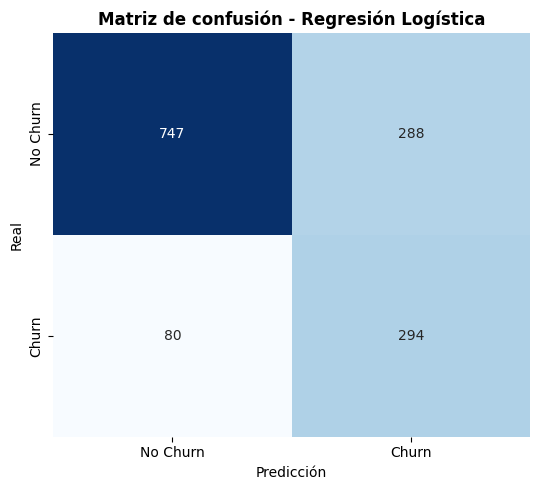

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax
)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - Regresión Logística', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Curva ROC

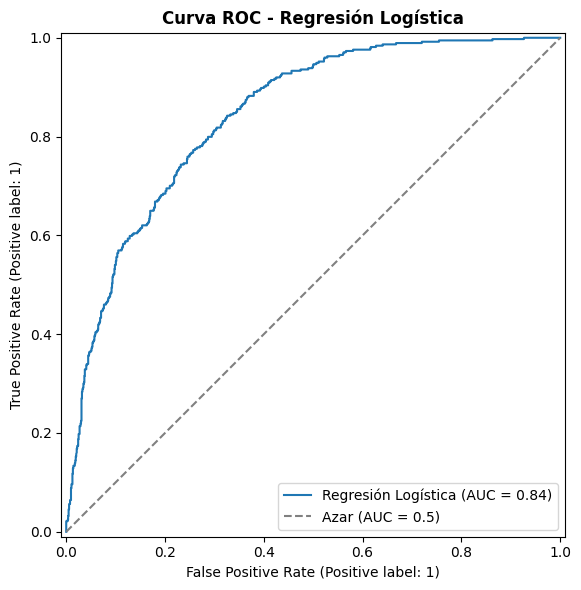

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name='Regresión Logística')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.5)')
ax.set_title('Curva ROC - Regresión Logística', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.4 Interpretación del resultado

- El **Accuracy** (score por defecto de sklearn) da una primera idea del desempeño general, pero al haber desbalance de clases (~27% Churn) puede sobreestimar la calidad del modelo. El Accuracy de 0.7388 debe leerse contra la referencia de predecir siempre la clase mayoritaria en este test (0.7346, no 0.50): la mejora sobre "no hacer nada" es modesta en Accuracy y se concentra en el Recall (0.7861 frente a 0 de la referencia).
- El **Recall** de la clase Churn es especialmente importante en este problema de negocio: interesa detectar la mayor cantidad posible de clientes que realmente van a abandonar, aunque eso implique sacrificar Precisión (aquí 0.5052 a umbral 0.5).
- El **AUC-ROC** resume la capacidad de separar ambas clases independientemente del umbral. No garantiza buena precisión ni utilidad operativa, por lo que se complementa con el PR-AUC (0.6339, frente a una prevalencia de churn de ~0.27), que no se infla por los verdaderos negativos.
- El intervalo de confianza del AUC-ROC en test (IC 95% [0.8214, 0.8630], bootstrap) indica cuánto podría variar la estimación con otra muestra de test del mismo tamaño.
- **Coherencia con la validación cruzada:** el AUC-ROC en test (0.8419) es consistente con el de CV en train (0.8453 ± 0.0123): no hay señal de sobreajuste ni de que el resultado dependa de esta partición. Es una comprobación de coherencia, no una prueba de ausencia de leakage; esa se apoya en el orden del pipeline, los controles de la sección 4.6 y la trazabilidad del split.
- `class_weight='balanced'` cambia el objetivo de entrenamiento: favorece el recall y **no produce probabilidades calibradas** para la prevalencia original. Si las probabilidades se usaran como riesgo habría que calibrarlas (dentro de train, por CV), y el umbral 0.5 es solo el de referencia, no uno justificado por costos de retención.
- Este resultado sirve como **línea base**: los modelos posteriores (Random Forest, Gradient Boosting, etc.) se comparan contra ella por **CV en train**, no por su score en test.


### 7.5 Lectura de coeficientes: ¿qué dicen `gender` y `PhoneService`?

Los coeficientes se leen aquí solo como **asociaciones condicionadas del modelo**, no como medida de importancia ni como prueba de utilidad:

- Las numéricas están estandarizadas (efecto por 1 desviación estándar) y las variables One-Hot van en 0/1 (efecto por cambio de categoría), así que sus magnitudes **no son directamente comparables**.
- La regularización L2 y la colinealidad alteran magnitudes e incluso signos: por ejemplo, `MonthlyCharges` tiene asociación marginal positiva con Churn en el EDA pero coeficiente negativo aquí, probablemente por su colinealidad con `InternetService` y los servicios adicionales.
- Un coeficiente pequeño no confirma ausencia de aporte incremental, ni uno grande confirma importancia.

El aporte real de estas variables se evaluó con la ablación por CV de la sección 4.7.


In [22]:
coeficientes = pd.Series(log_reg.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)

ranking = coeficientes.reset_index()
ranking.columns = ['variable', 'coeficiente']
ranking.insert(0, 'puesto', range(1, len(ranking) + 1))

print("Ranking completo por magnitud absoluta del coeficiente:")
print(ranking.to_string(index=False))

print("\nCoeficientes específicos de gender y PhoneService (con su puesto):")
print(ranking[ranking['variable'].str.contains('gender|PhoneService')].to_string(index=False))


Ranking completo por magnitud absoluta del coeficiente:
 puesto                                   variable  coeficiente
      1                     cat__Contract_Two year    -1.414771
      2                                num__tenure    -1.140778
      3                    cat__InternetService_No    -1.095142
      4           cat__InternetService_Fiber optic     1.058314
      5                     cat__Contract_One year    -0.721303
      6                          num__TotalCharges     0.468794
      7        cat__PaymentMethod_Electronic check     0.401170
      8                    cat__OnlineSecurity_Yes    -0.363730
      9                   cat__StreamingMovies_Yes     0.358041
     10                  cat__PaperlessBilling_Yes     0.338012
     11                       cat__StreamingTV_Yes     0.331868
     12                        num__MonthlyCharges    -0.309501
     13                       cat__TechSupport_Yes    -0.298389
     14                     cat__MultipleLines_Y

> **Corrección respecto a la lectura inicial.** Para `gender` (coeficiente 0.032, puesto 21 de 24) la conclusión del EDA se sostiene: aporta muy poco a este modelo. Para `PhoneService` **no se sostiene igual de bien**: su coeficiente (−0.289) lo ubica en el puesto 15 de 24, por encima —en magnitud— de `Dependents` (−0.227), `SeniorCitizen`, `Partner` y otras variables que sí se consideran informativas. No es de los coeficientes más grandes, pero tampoco es de los más pequeños.
>
> Una parte de esa magnitud es probablemente un artefacto de colinealidad, no de aporte real: `PhoneService_Yes` (−0.289) y `MultipleLines_Yes` (+0.294) tienen coeficientes casi opuestos y de magnitud casi idéntica, consistente con que ambas codifican información muy relacionada (sin `PhoneService` no puede haber `MultipleLines`). Con regularización L2 y variables correlacionadas, el modelo puede repartir peso entre ellas de forma inestable — el propio notebook ya advierte esto en la sección 4.3.c, pero la conclusión de la celda anterior no lo aplicó de forma consistente a `PhoneService`.
>
> **Conclusión corregida:** decir que el modelo "confirma" que `PhoneService` aporta poco no está respaldado por su coeficiente individual. Para una afirmación más sólida se hizo la ablación por CV de la sección 4.7 (sin `PhoneService`, y sin `PhoneService`/`MultipleLines` juntas), en lugar de leer solo la magnitud del coeficiente.

## 8. Resumen y próximos pasos

- El target se transformó a binario (0/1).
- `TotalCharges` se convirtió a numérico; sus 8 nulos en train (3 en test) se verificaron explícitamente como clientes con `tenure = 0` antes de imputarlos con 0. Se comparó por CV esta imputación contra mediana + indicador (con la mediana aprendida dentro de cada fold): AUC-ROC 0.8460 ± 0.0124 vs 0.8460 ± 0.0125, así que la elección no es crítica para el resultado.
- Se resolvieron los hallazgos del EDA:
  - Se colapsaron las categorías redundantes ("No internet service" / "No phone service"): la información sigue disponible en `InternetService` y `PhoneService`; cambia la parametrización, no el contenido.
  - Se agregó `AvgChargePerMonth`, usando `MonthlyCharges` como proxy cuando `tenure = 0` (la división 0/0 sería NaN) y verificando que no queden valores no finitos. Su correlación de 0.9963 con `MonthlyCharges` explica que su coeficiente sea pequeño (−0.033, puesto 20 de 24).
  - Se conservaron `gender` y `PhoneService`. Los coeficientes se leen solo como asociaciones condicionadas: `gender` es pequeño (0.032, puesto 21 de 24) y `PhoneService` no lo es (−0.289, puesto 15 de 24) pero se compensa con `MultipleLines`. La ablación por CV (sección 4.7) no encontró aporte medible de `gender` ni de `PhoneService` por separado (cambio de AUC-ROC +0.0002 ± 0.0004 y +0.0002 ± 0.0004 al retirarlas), ni de `AvgChargePerMonth` (+0.0006 ± 0.0004 al retirarla); solo el par `PhoneService`/`MultipleLines` aporta algo pequeño (PR-AUC -0.0105 ± 0.0074 al retirarlas juntas). Las variables se mantienen para no cambiar el pipeline ya reportado; eliminar `AvgChargePerMonth` queda como decisión abierta.
- **Protocolo de validación fijado:** toda comparación de modelos y ajuste de hiperparámetros se hace por validación cruzada dentro de `train`, con preprocesamiento y modelo en un mismo `Pipeline` (sección 4.6). `test` se evalúa una sola vez (sección 7), y ese resultado no debe usarse para seguir decidiendo entre modelos.
- La validación cruzada (AUC-ROC 0.8453 ± 0.0123) es coherente con el resultado en test (0.8419, IC 95% [0.8214, 0.8630]), y los controles de sanidad (etiquetas permutadas → 0.4873; `DummyClassifier` → ~0.50) no muestran señales de *leakage* ni de un desempeño inflado por el desbalance.
- Se cuantificaron los perfiles idénticos entre train y test: 13 filas de test (0.92%) coinciden exactamente con algún perfil de train, en 14 parejas (7 con la misma etiqueta y 7 con etiqueta distinta). Es un nivel esperable en un dataset con predictores mayormente categóricos y no indica por sí solo contaminación (los `customerID` son únicos, los índices no se solapan y la partición se guarda en `train_index.csv` / `test_index.csv` y se verifica contra la del EDA). Sin campos de hogar o cuenta no se puede descartar por completo dependencia entre clientes.
- Se añadieron PR-AUC, un intervalo de confianza por bootstrap para el AUC-ROC, la referencia de `DummyClassifier`, y la verificación de convergencia de la Regresión Logística (57 de 1000 iteraciones permitidas).
- **Limitación de alcance (sección 2.1):** el score mide clasificación dentro de un corte, no necesariamente predicción de churn futuro; debe declararse así en el informe. La disponibilidad temporal de cada variable no se puede verificar solo con los datos y queda como supuesto documentado.
- Los conjuntos `X_train_processed` / `X_test_processed` y `y_train` / `y_test` quedan listos para el ajuste final de modelos adicionales (Random Forest, Gradient Boosting, etc.), que deben compararse contra esta línea base **por CV en train** (con `Pipeline`, no con estas matrices ya transformadas), no por su score en test.
